In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_excel('E:\Data Analysis Bootcamp\Exploratory Data Analysis\carousell\(MS) Data Internship_ Technical Assignment Dataset.xlsx')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HIMANSHU\AppData\Local\Temp\ipykernel_100680\3754494768.py:1: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_excel('E:\Data Analysis Bootcamp\Exploratory Data Analysis\carousell\(MS) Data Internship_ Technical Assignment Dataset.xlsx')


,date,hour_utc,country_name,parent_name,category_name,condition,listings_created,avg_price_usd
0,2020-02-10,0,Singapore,Electronics,Audio,New,23,21.473065
1,2020-02-10,0,Singapore,Women's Fashion,Dresses & Skirts (Women's Clothes),New,15,14.590833
2,2020-02-10,0,Singapore,Gardening,Flowers & Bouquets,New,12,41.216703
3,2020-02-10,0,Singapore,Women's Fashion,Tops (Women's Clothes),Used,11,11.852870
4,2020-02-10,0,Singapore,Electronics,Electronics & Gadgets - Others,New,11,41.691210


In [3]:
df.info

<bound method DataFrame.info of             date  hour_utc country_name      parent_name  \
0     2020-02-10         0    Singapore      Electronics   
1     2020-02-10         0    Singapore  Women's Fashion   
2     2020-02-10         0    Singapore        Gardening   
3     2020-02-10         0    Singapore  Women's Fashion   
4     2020-02-10         0    Singapore      Electronics   
...          ...       ...          ...              ...   
11058 2020-02-16        23    Singapore     Toys & Games   
11059 2020-02-16        23    Singapore  Women's Fashion   
11060 2020-02-16        23    Singapore  Women's Fashion   
11061 2020-02-16        23    Singapore  Women's Fashion   
11062 2020-02-16        23    Singapore  Women's Fashion   

                                 category_name condition  listings_created  \
0                                        Audio       New                23   
1           Dresses & Skirts (Women's Clothes)       New                15   
2            

In [4]:
df.describe()

,date,hour_utc,listings_created,avg_price_usd
count,11063,11063.000000,11063.000000,1.106300e+04
mean,2020-02-13 01:01:41.853023488,10.060653,8.920184,7.716494e+05
min,2020-02-10 00:00:00,0.000000,1.000000,0.000000e+00
25%,2020-02-11 00:00:00,5.000000,2.000000,1.269390e+01
50%,2020-02-13 00:00:00,10.000000,4.000000,2.886405e+01
75%,2020-02-15 00:00:00,15.000000,10.000000,8.209124e+01
max,2020-02-16 00:00:00,23.000000,139.000000,6.386866e+09
std,NaN,6.202457,13.412461,6.379602e+07


In [6]:
df.shape

(11063, 8)

In [7]:
df.columns

Index(['date', 'hour_utc', 'country_name', 'parent_name', 'category_name',
       'condition', 'listings_created', 'avg_price_usd'],
      dtype='object')

In [8]:
df['category_name'].unique()

array(['Audio', "Dresses & Skirts (Women's Clothes)",
       'Flowers & Bouquets', "Tops (Women's Clothes)",
       'Electronics & Gadgets - Others', 'Computer Parts & Accessories',
       'Bricks & Figurines', 'Board Games & Cards',
       'Video Games (Video Gaming)', "Earrings (Women's Jewellery)",
       'Muslimah Fashion', "Others (Women's Clothes)", 'Plants',
       "Hair Accessories (Women's Accessories)",
       'Toys & Board Games - Others', "Outerwear (Women's Clothes)",
       'Stuffed Toys', "Pants, Jeans & Shorts (Women's Clothes)",
       "Handbags (Women's Bags & Wallets)",
       "Flats & Sandals (Women's Shoes)", "Heels (Women's Shoes)",
       'In-Game Products (Video Gaming)', "Women's Watches",
       'Laptops (Computers)',
       "Eyewear & Sunglasses (Women's Accessories)",
       "Boots (Women's Shoes)", 'Consoles (Video Gaming)',
       "Socks & Hosiery (Women's Accessories)",
       "Sling Bags (Women's Bags & Wallets)",
       'Gaming Accessories (Video Gaming

In [9]:
df.isnull()

,date,hour_utc,country_name,parent_name,category_name,condition,listings_created,avg_price_usd
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
11058,False,False,False,False,False,False,False,False
11059,False,False,False,False,False,False,False,False
11060,False,False,False,False,False,False,False,False
11061,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

date                0
hour_utc            0
country_name        0
parent_name         0
category_name       0
condition           0
listings_created    0
avg_price_usd       0
dtype: int64

In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11058    False
11059    False
11060    False
11061    False
11062    False
Length: 11063, dtype: bool

In [12]:
df[df.duplicated()]

,date,hour_utc,country_name,parent_name,category_name,condition,listings_created,avg_price_usd


In [13]:
df['condition'].unique()

array(['New', 'Used', 'unspecified'], dtype=object)

In [14]:
df['country_name']=df['country_name'].str.strip()
df['condition']=df['condition'].str.lower()

In [15]:
temporal_data = df.groupby('date').agg(
    total_listings=('listings_created', 'sum'),
    avg_price=('avg_price_usd', 'mean')
).reset_index()

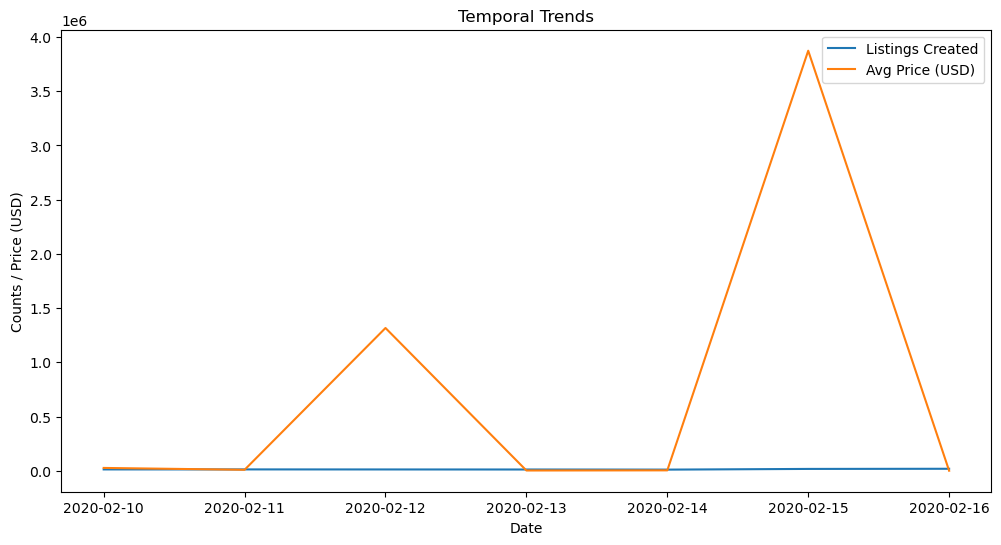

In [16]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=temporal_data, x='date', y='total_listings', label='Listings Created')
sns.lineplot(data=temporal_data, x='date', y='avg_price', label='Avg Price (USD)')
plt.title('Temporal Trends')
plt.xlabel('Date')
plt.ylabel('Counts / Price (USD)')
plt.legend()
plt.show()

In [17]:
country_data = df.groupby('country_name').agg(
    total_listings=('listings_created', 'sum'),
    avg_price=('avg_price_usd', 'mean')
).reset_index()

C:\Users\HIMANSHU\AppData\Local\Temp\ipykernel_100680\971689443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_data, x='country_name', y='total_listings', palette='viridis')


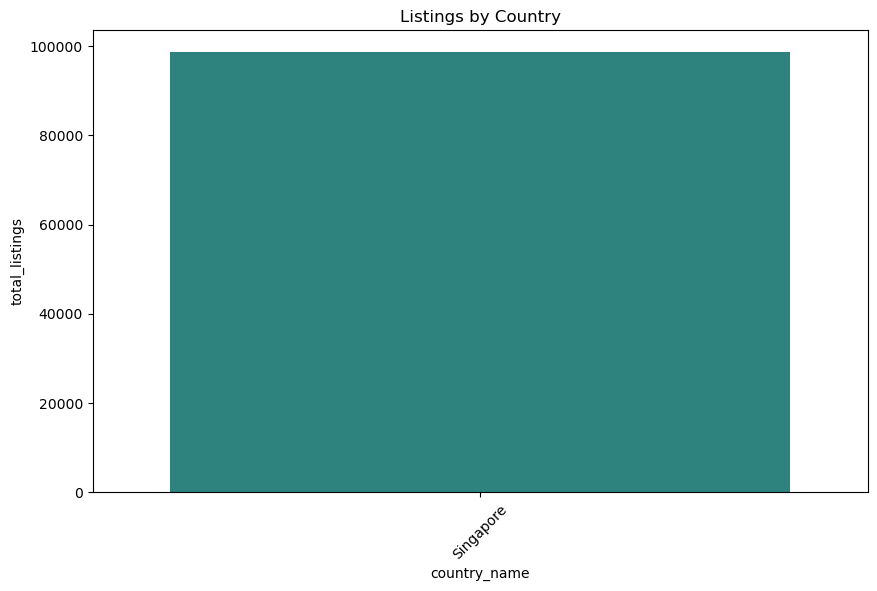

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=country_data, x='country_name', y='total_listings', palette='viridis')
plt.title('Listings by Country')
plt.xticks(rotation=45)
plt.show()


In [19]:
category_data = df.groupby('category_name').agg(
    total_listings=('listings_created', 'sum'),
    avg_price=('avg_price_usd', 'mean')
).reset_index()

C:\Users\HIMANSHU\AppData\Local\Temp\ipykernel_100680\3125529253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_data, x='category_name', y='total_listings', palette='coolwarm')


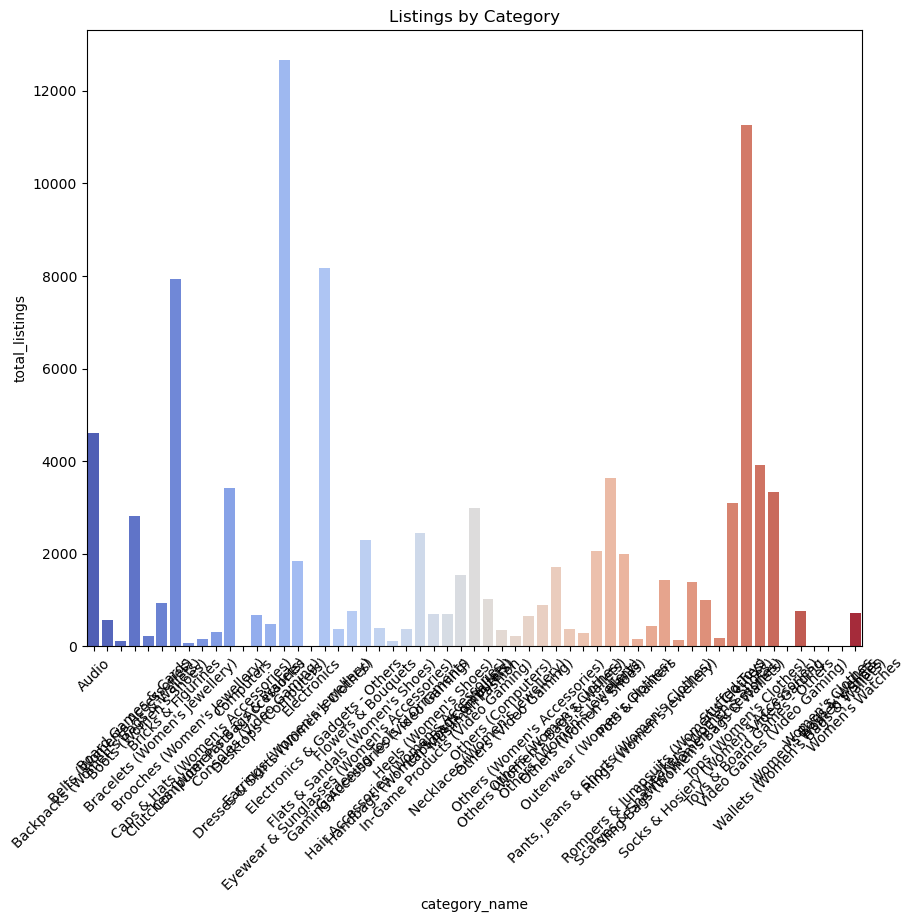

In [21]:
plt.figure(figsize=(10, 8))
sns.barplot(data=category_data, x='category_name', y='total_listings', palette='coolwarm')
plt.title('Listings by Category')
plt.xticks(rotation=45)
plt.show()

In [22]:
condition_data = df.groupby('condition').agg(
    total_listings=('listings_created', 'sum'),
    avg_price=('avg_price_usd', 'mean')
).reset_index()
